# LTSF-Linear Demo
**Paper:** *Are Transformers Effective for Time Series Forecasting?* — Zeng et al., AAAI 2023  
**arXiv:** https://arxiv.org/abs/2205.13504  
**Official repo:** https://github.com/cure-lab/LTSF-Linear

This notebook implements the three LTSF-Linear models (Linear, NLinear, DLinear) from scratch in PyTorch,
trains them on synthetic data, and visualises the results.

## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0


## 2. Generate Synthetic Time Series Data

We create a multi-variate synthetic series with trend, seasonality, and noise — mimicking the structure of the ETT datasets used in the paper.

Data shape: (4000, 7)
Train: (2800, 7), Val: (400, 7), Test: (800, 7)


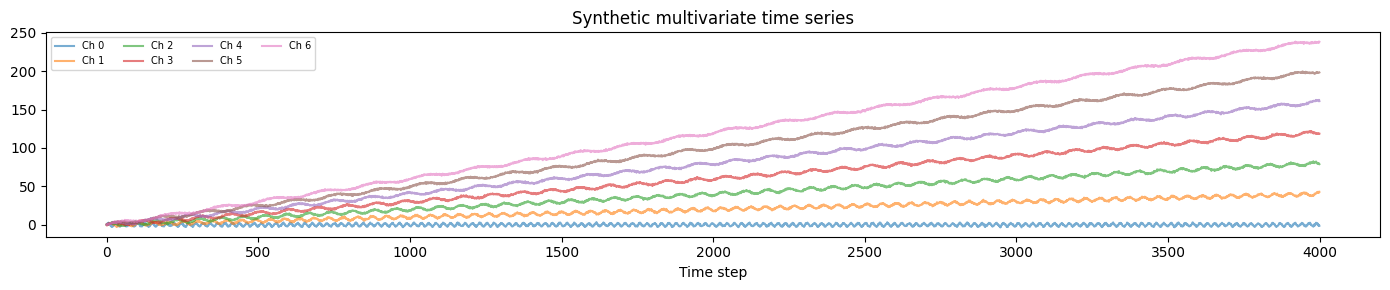

In [3]:
N = 4000      # total time steps
C = 7         # number of variates (matching ETT datasets)
t = np.arange(N)

# Build 7 channels with different trend slopes, periods, and noise levels
data = np.stack([
    0.01 * i * t
    + 2.0 * np.sin(2 * np.pi * t / (24 * (i + 1)))
    + np.random.randn(N) * 0.5
    for i in range(C)
], axis=1).astype(np.float32)   # shape: (N, C)

# Train / val / test split  (70 / 10 / 20)
n_train = int(0.7 * N)
n_val   = int(0.1 * N)
train_data = data[:n_train]
val_data   = data[n_train : n_train + n_val]
test_data  = data[n_train + n_val :]

print(f"Data shape: {data.shape}")
print(f"Train: {train_data.shape}, Val: {val_data.shape}, Test: {test_data.shape}")

plt.figure(figsize=(14, 3))
for i in range(C):
    plt.plot(data[:, i], alpha=0.6, label=f"Ch {i}")
plt.title("Synthetic multivariate time series")
plt.xlabel("Time step")
plt.legend(loc="upper left", ncol=4, fontsize=7)
plt.tight_layout()
plt.show()

## 3. Normalise the Dataset

Zero-mean unit-variance normalisation using training set statistics only.

In [4]:
mean = train_data.mean(axis=0)
std  = train_data.std(axis=0) + 1e-8

train_norm = (train_data - mean) / std
val_norm   = (val_data   - mean) / std
test_norm  = (test_data  - mean) / std

print("Per-channel mean (train):", mean.round(2))
print("Per-channel std  (train):", std.round(2))

Per-channel mean (train): [2.000e-02 1.398e+01 2.799e+01 4.201e+01 5.601e+01 6.999e+01 8.401e+01]
Per-channel std  (train): [ 1.49  8.22 16.2  24.26 32.35 40.44 48.52]


## 4. Dataset & DataLoader

In [6]:
SEQ_LEN  = 336   # look-back window  (L)
PRED_LEN = 36    # forecast horizon  (T)

class TSDataset(Dataset):
    def __init__(self, arr, seq_len, pred_len):
        self.arr      = torch.tensor(arr, dtype=torch.float32)
        self.seq_len  = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.arr) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.arr[idx          : idx + self.seq_len]
        y = self.arr[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return x, y   # shapes: (L, C), (T, C)

train_ds = TSDataset(train_norm, SEQ_LEN, PRED_LEN)
val_ds   = TSDataset(val_norm,   SEQ_LEN, PRED_LEN)
test_ds  = TSDataset(test_norm,  SEQ_LEN, PRED_LEN)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 75, Val batches: 1, Test batches: 14


## 5. Model Implementations

### 5a. Linear — one linear layer per channel

$$\hat{X} = W \cdot X, \quad W \in \mathbb{R}^{T \times L}$$

In [7]:
class LinearModel(nn.Module):
    """One shared linear layer mapping (L,) -> (T,), applied identically to each channel."""
    def __init__(self, seq_len: int, pred_len: int):
        super().__init__()
        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)  -> permute to (B, C, L) -> linear -> (B, C, T) -> permute back
        return self.linear(x.permute(0, 2, 1)).permute(0, 2, 1)

### 5b. NLinear — normalisation via last-value subtraction

$$\hat{X} = W \cdot (X - x_L) + x_L$$

In [8]:
class NLinear(nn.Module):
    """
    Subtract the last observation, apply a linear layer, then add it back.
    Handles distribution shift between training and test windows.
    """
    def __init__(self, seq_len: int, pred_len: int):
        super().__init__()
        self.linear = nn.Linear(seq_len, pred_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)
        last = x[:, -1:, :]          # (B, 1, C)
        x_norm = x - last            # remove the last-step offset
        out = self.linear(x_norm.permute(0, 2, 1)).permute(0, 2, 1)  # (B, T, C)
        return out + last            # add offset back

### 5c. DLinear — decomposition into trend and seasonal components

$$X_\text{trend} = \text{MovingAvg}(X), \quad X_\text{seasonal} = X - X_\text{trend}$$
$$\hat{X} = W_s \cdot X_\text{seasonal} + W_t \cdot X_\text{trend}$$

In [9]:
class MovingAvg(nn.Module):
    """Centred moving average (with symmetric boundary padding)."""
    def __init__(self, kernel_size: int = 25):
        super().__init__()
        self.k = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)
        pad = (self.k - 1) // 2
        x_pad = torch.cat([x[:, :1, :].expand(-1, pad, -1),
                           x,
                           x[:, -1:, :].expand(-1, pad, -1)], dim=1)
        # AvgPool1d expects (B, C, L)
        trend = self.avg(x_pad.permute(0, 2, 1)).permute(0, 2, 1)
        return trend


class DLinear(nn.Module):
    """
    Decomposition-Linear (DLinear).
    Splits the input into trend and seasonal components via a moving average,
    then applies separate linear layers to each.
    """
    def __init__(self, seq_len: int, pred_len: int, kernel_size: int = 25):
        super().__init__()
        self.decomp = MovingAvg(kernel_size)
        self.linear_seasonal = nn.Linear(seq_len, pred_len)
        self.linear_trend    = nn.Linear(seq_len, pred_len)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, L, C)
        trend    = self.decomp(x)
        seasonal = x - trend
        out_s = self.linear_seasonal(seasonal.permute(0, 2, 1)).permute(0, 2, 1)
        out_t = self.linear_trend   (trend.permute   (0, 2, 1)).permute(0, 2, 1)
        return out_s + out_t   # (B, T, C)


# Quick sanity check
dummy = torch.randn(4, SEQ_LEN, C)
for name, model in [("Linear", LinearModel(SEQ_LEN, PRED_LEN)),
                    ("NLinear", NLinear(SEQ_LEN, PRED_LEN)),
                    ("DLinear", DLinear(SEQ_LEN, PRED_LEN))]:
    out = model(dummy)
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:10s}  output shape: {tuple(out.shape)}   params: {params:,}")

Linear      output shape: (4, 36, 7)   params: 12,132
NLinear     output shape: (4, 36, 7)   params: 12,132
DLinear     output shape: (4, 36, 7)   params: 24,264


## 6. Training Loop

In [10]:
def train(model, train_loader, val_loader, epochs=20, lr=1e-3, verbose=True):
    criterion = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train": [], "val": []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            optimiser.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimiser.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                pred = model(x)
                val_loss += criterion(pred, y).item()
        val_loss /= len(val_loader)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}/{epochs}  train MSE: {train_loss:.4f}  val MSE: {val_loss:.4f}")

    return history


EPOCHS = 30

print("=== Training Linear ===")
linear_model  = LinearModel(SEQ_LEN, PRED_LEN)
hist_linear   = train(linear_model, train_loader, val_loader, epochs=EPOCHS)

print("\n=== Training NLinear ===")
nlinear_model = NLinear(SEQ_LEN, PRED_LEN)
hist_nlinear  = train(nlinear_model, train_loader, val_loader, epochs=EPOCHS)

print("\n=== Training DLinear ===")
dlinear_model = DLinear(SEQ_LEN, PRED_LEN)
hist_dlinear  = train(dlinear_model, train_loader, val_loader, epochs=EPOCHS)

=== Training Linear ===
Epoch   1/30  train MSE: 0.0956  val MSE: 0.0313
Epoch   5/30  train MSE: 0.0233  val MSE: 0.0234
Epoch  10/30  train MSE: 0.0210  val MSE: 0.0209
Epoch  15/30  train MSE: 0.0195  val MSE: 0.0199
Epoch  20/30  train MSE: 0.0185  val MSE: 0.0193
Epoch  25/30  train MSE: 0.0179  val MSE: 0.0188
Epoch  30/30  train MSE: 0.0175  val MSE: 0.0196

=== Training NLinear ===
Epoch   1/30  train MSE: 0.0548  val MSE: 0.0265
Epoch   5/30  train MSE: 0.0221  val MSE: 0.0205
Epoch  10/30  train MSE: 0.0201  val MSE: 0.0197
Epoch  15/30  train MSE: 0.0188  val MSE: 0.0190
Epoch  20/30  train MSE: 0.0184  val MSE: 0.0188
Epoch  25/30  train MSE: 0.0179  val MSE: 0.0189
Epoch  30/30  train MSE: 0.0177  val MSE: 0.0192

=== Training DLinear ===
Epoch   1/30  train MSE: 0.0912  val MSE: 0.0298
Epoch   5/30  train MSE: 0.0223  val MSE: 0.0215
Epoch  10/30  train MSE: 0.0193  val MSE: 0.0205
Epoch  15/30  train MSE: 0.0182  val MSE: 0.0192
Epoch  20/30  train MSE: 0.0176  val MSE: 

## 7. Evaluate on Test Set

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2 \qquad \text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|\hat{y}_i - y_i|$$

We also include a **naïve baseline** that repeats the last observed value across the entire forecast horizon.

In [11]:
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x))
            trues.append(y)
    preds = torch.cat(preds, dim=0)
    trues = torch.cat(trues, dim=0)
    mse = ((preds - trues) ** 2).mean().item()
    mae = (preds - trues).abs().mean().item()
    return mse, mae, preds, trues


def naive_baseline(loader):
    """Repeat the last value of the look-back window across the forecast horizon."""
    preds, trues = [], []
    for x, y in loader:
        last = x[:, -1:, :].expand_as(y)
        preds.append(last)
        trues.append(y)
    preds = torch.cat(preds, dim=0)
    trues = torch.cat(trues, dim=0)
    mse = ((preds - trues) ** 2).mean().item()
    mae = (preds - trues).abs().mean().item()
    return mse, mae


results = {}
for name, model in [("Linear",  linear_model),
                    ("NLinear", nlinear_model),
                    ("DLinear", dlinear_model)]:
    mse, mae, preds, trues = evaluate(model, test_loader)
    results[name] = {"mse": mse, "mae": mae, "preds": preds, "trues": trues}

naive_mse, naive_mae = naive_baseline(test_loader)
results["Naïve"] = {"mse": naive_mse, "mae": naive_mae}

print(f"{'Model':<10}  {'MSE':>8}  {'MAE':>8}")
print("-" * 32)
for name, r in results.items():
    print(f"{name:<10}  {r['mse']:>8.4f}  {r['mae']:>8.4f}")

Model            MSE       MAE
--------------------------------
Linear        0.0221    0.0835
NLinear       0.0204    0.0702
DLinear       0.0238    0.0899
Naïve         0.2932    0.2359


## 8. Visualise Predictions

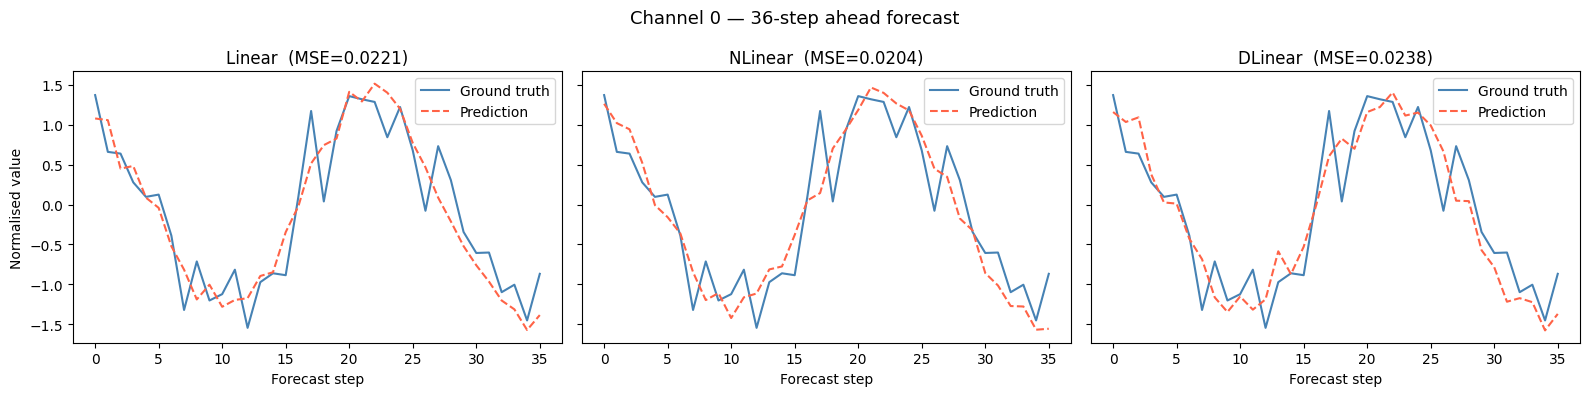

In [12]:
SAMPLE_IDX = 0   # which test sample to plot
CHANNEL    = 0   # which variate to plot

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
model_names = ["Linear", "NLinear", "DLinear"]

for ax, name in zip(axes, model_names):
    true  = results[name]["trues"][SAMPLE_IDX, :, CHANNEL].numpy()
    pred  = results[name]["preds"][SAMPLE_IDX, :, CHANNEL].detach().numpy()
    steps = np.arange(len(true))
    ax.plot(steps, true, label="Ground truth", color="steelblue")
    ax.plot(steps, pred, label="Prediction",   color="tomato", linestyle="--")
    ax.set_title(f"{name}  (MSE={results[name]['mse']:.4f})")
    ax.set_xlabel("Forecast step")
    ax.legend()

axes[0].set_ylabel("Normalised value")
fig.suptitle(f"Channel {CHANNEL} — {PRED_LEN}-step ahead forecast", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Visualise DLinear Weights

A key insight from the paper: the learned weights of the seasonal branch reveal the **periodicity** baked into the data.
Each row of $W_s$ corresponds to one forecast step; bright columns at regular intervals indicate the model has learned to attend to periodic past positions.

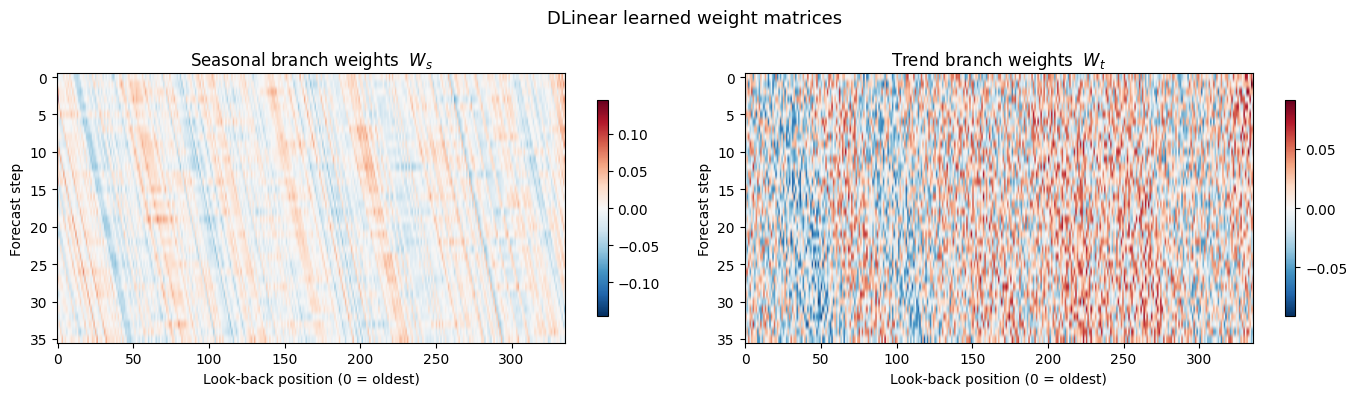

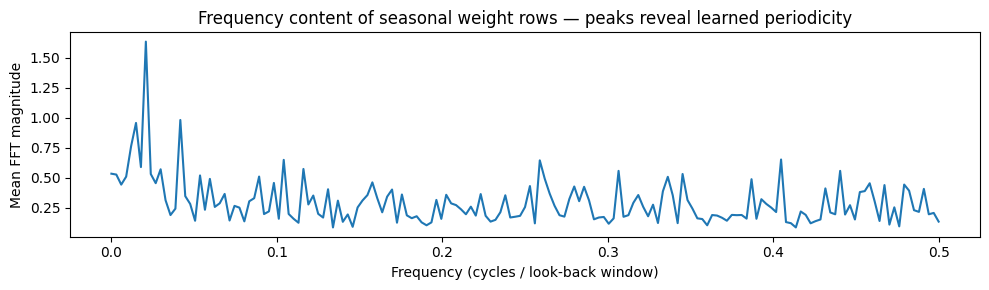

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

W_seasonal = dlinear_model.linear_seasonal.weight.detach().numpy()  # (T, L)
W_trend    = dlinear_model.linear_trend.weight.detach().numpy()     # (T, L)

for ax, W, title in zip(axes,
                        [W_seasonal, W_trend],
                        ["Seasonal branch weights  $W_s$",
                         "Trend branch weights  $W_t$"]):
    im = ax.imshow(W, aspect="auto", cmap="RdBu_r",
                   vmin=-np.abs(W).max(), vmax=np.abs(W).max())
    ax.set_xlabel("Look-back position (0 = oldest)")
    ax.set_ylabel("Forecast step")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("DLinear learned weight matrices", fontsize=13)
plt.tight_layout()
plt.show()

# Row-wise (per forecast step) power spectrum — reveals periodicity
fig, ax = plt.subplots(figsize=(10, 3))
mean_fft = np.abs(np.fft.rfft(W_seasonal, axis=1)).mean(axis=0)
freqs = np.fft.rfftfreq(SEQ_LEN)
ax.plot(freqs, mean_fft)
ax.set_xlabel("Frequency (cycles / look-back window)")
ax.set_ylabel("Mean FFT magnitude")
ax.set_title("Frequency content of seasonal weight rows — peaks reveal learned periodicity")
plt.tight_layout()
plt.show()